In [76]:
#packages

import os
import numpy as np
import matplotlib.pyplot as plt

neuer_pfad = "/Users/trinity/Desktop/bachelor.thesis/measurements/divergence_voltage"

os.chdir(neuer_pfad)

In [77]:
#norm
 #Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

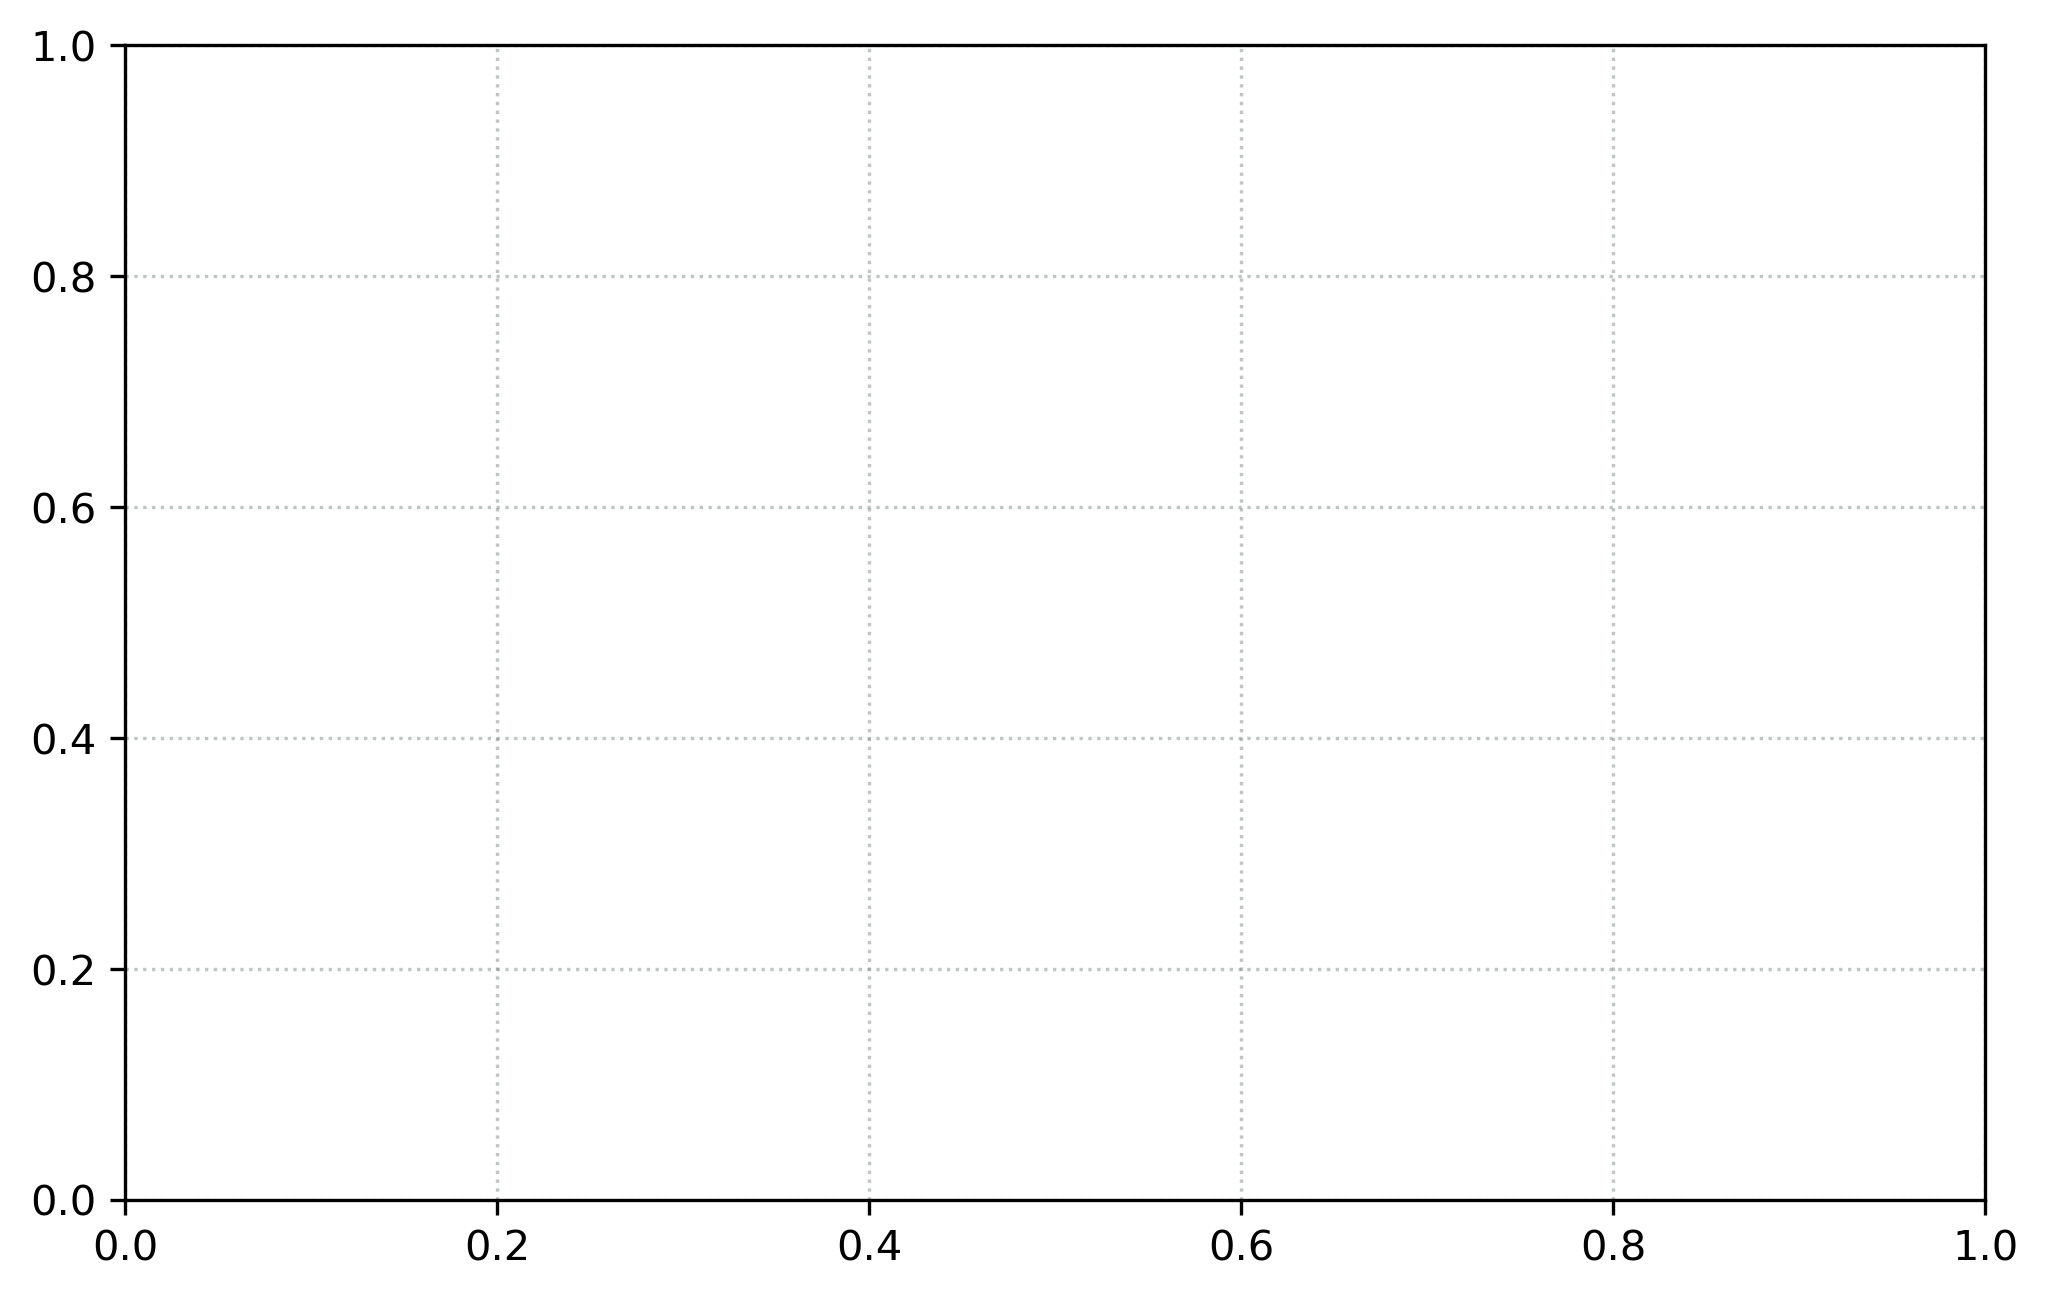

In [83]:
#hier nur messwerte ohne theorie mit s-f als x 
#mit error

fig, (ax1) = plt.subplots(figsize=(8, 5))

data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/divergence_voltage/div_V_voltage_increasing.csv',
    delimiter=','
)
voltage_div_up = data[:, 0]
divergence_x_up = data[:, 1] #
divergence_y_up= data[:, 3]

M2_x_up = data[:, 5]
M2_x_error_up = data[:, 6]
M2_y_up = data[:, 7]
M2_y_error_up = data[:, 8]

voltage_sensor_up = data[:, 11]
distance_sensor_up = data[:, 13]
#________________________________________ERRORS___________________________
#from M2 measurmement:
divergence_y_error_up = data[:, 4]
divergence_x_error_up = data[:, 2]
# voltage: error= ±(0.1% vom Messwert + 5 Digits der Auflösung im jeweiligen Bereich)
def calc_voltage_error(v):
    if v <= 1.0:  # 1000 mV Bereich (Auflösung 0.1 mV = 0.0001 V)
        return 0.001 * v + 5 * 0.0001
    elif v <= 10.0:  # 10 V Bereich (Auflösung 1 mV = 0.001 V)
        return 0.001 * v + 5 * 0.001
    elif v <= 100.0:  # 100 V Bereich (Auflösung 10 mV = 0.01 V)
        return 0.001 * v + 5 * 0.01
    else:  # 1500 V Bereich (Auflösung 100 mV = 0.1 V)
        return 0.001 * v + 5 * 0.1

voltage_div_error_up = calc_voltage_error(voltage_div_up)

#ax2 = ax1.twinx()

ax1.errorbar(voltage_div_up, divergence_x_up, xerr=voltage_div_error_up, yerr = divergence_x_error_up,fmt ='x-', color='red', label=r'divergence x with increasing voltage')
ax1.errorbar(voltage_div_up, divergence_y_up, xerr=voltage_div_error_up, yerr = divergence_y_error_up,fmt ='x-', color='darkred', label=r'divergence y with increasing voltage')
#ax2.plot(voltage_sensor_up, distance_sensor_up, '-x', color='pink', label=r'distance measured)')

data2 = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/divergence_voltage/div_V_voltage_decreasing.csv',
    delimiter=','
)
voltage_div_down = data2[:, 0]
divergence_x_down = data2[:, 1] #i
divergence_y_down= data2[:, 3]
M2_x_down = data2[:, 5]
M2_x_error_down = data2[:, 6]
M2_y_down = data2[:, 7]
M2_y_error_down = data2[:, 8]

voltage_sensor_down = data2[:, 11]
distance_sensor_down = data2[:, 13]


#________________________________________ERRORS___________________________
#from M2 measurmement:
divergence_x_error_down = data2[:, 2]
divergence_y_error_down = data2[:, 4]
# voltage: error= ±(0.1% vom Messwert + 5 Digits der Auflösung im jeweiligen Bereich)
voltage_div_error_down = calc_voltage_error(voltage_div_down)

ax1.errorbar(voltage_div_down, divergence_x_down, xerr=voltage_div_error_down, yerr = divergence_x_error_down,fmt ='x-', color='blue', label=r'divergence x with decreasing voltage')
ax1.errorbar(voltage_div_down, divergence_y_down, yerr = divergence_y_error_down,fmt ='x-', color='darkblue', label=r'divergence y with decreasing voltage')
#ax2.plot(voltage_sensor_down, distance_sensor_down, '-x', color='#007A87', label=r'distance measured)')


plt.xlabel(r"Voltage [V]")
plt.ylabel(r"Far-Field Divergence [mrad]")
plt.title('Far Field Divergence vs. Voltage Measurement')

plt.legend()
plt.tight_layout()
#plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/divergence_vs_mechanival_displacement_full.pdf")
plt.show()

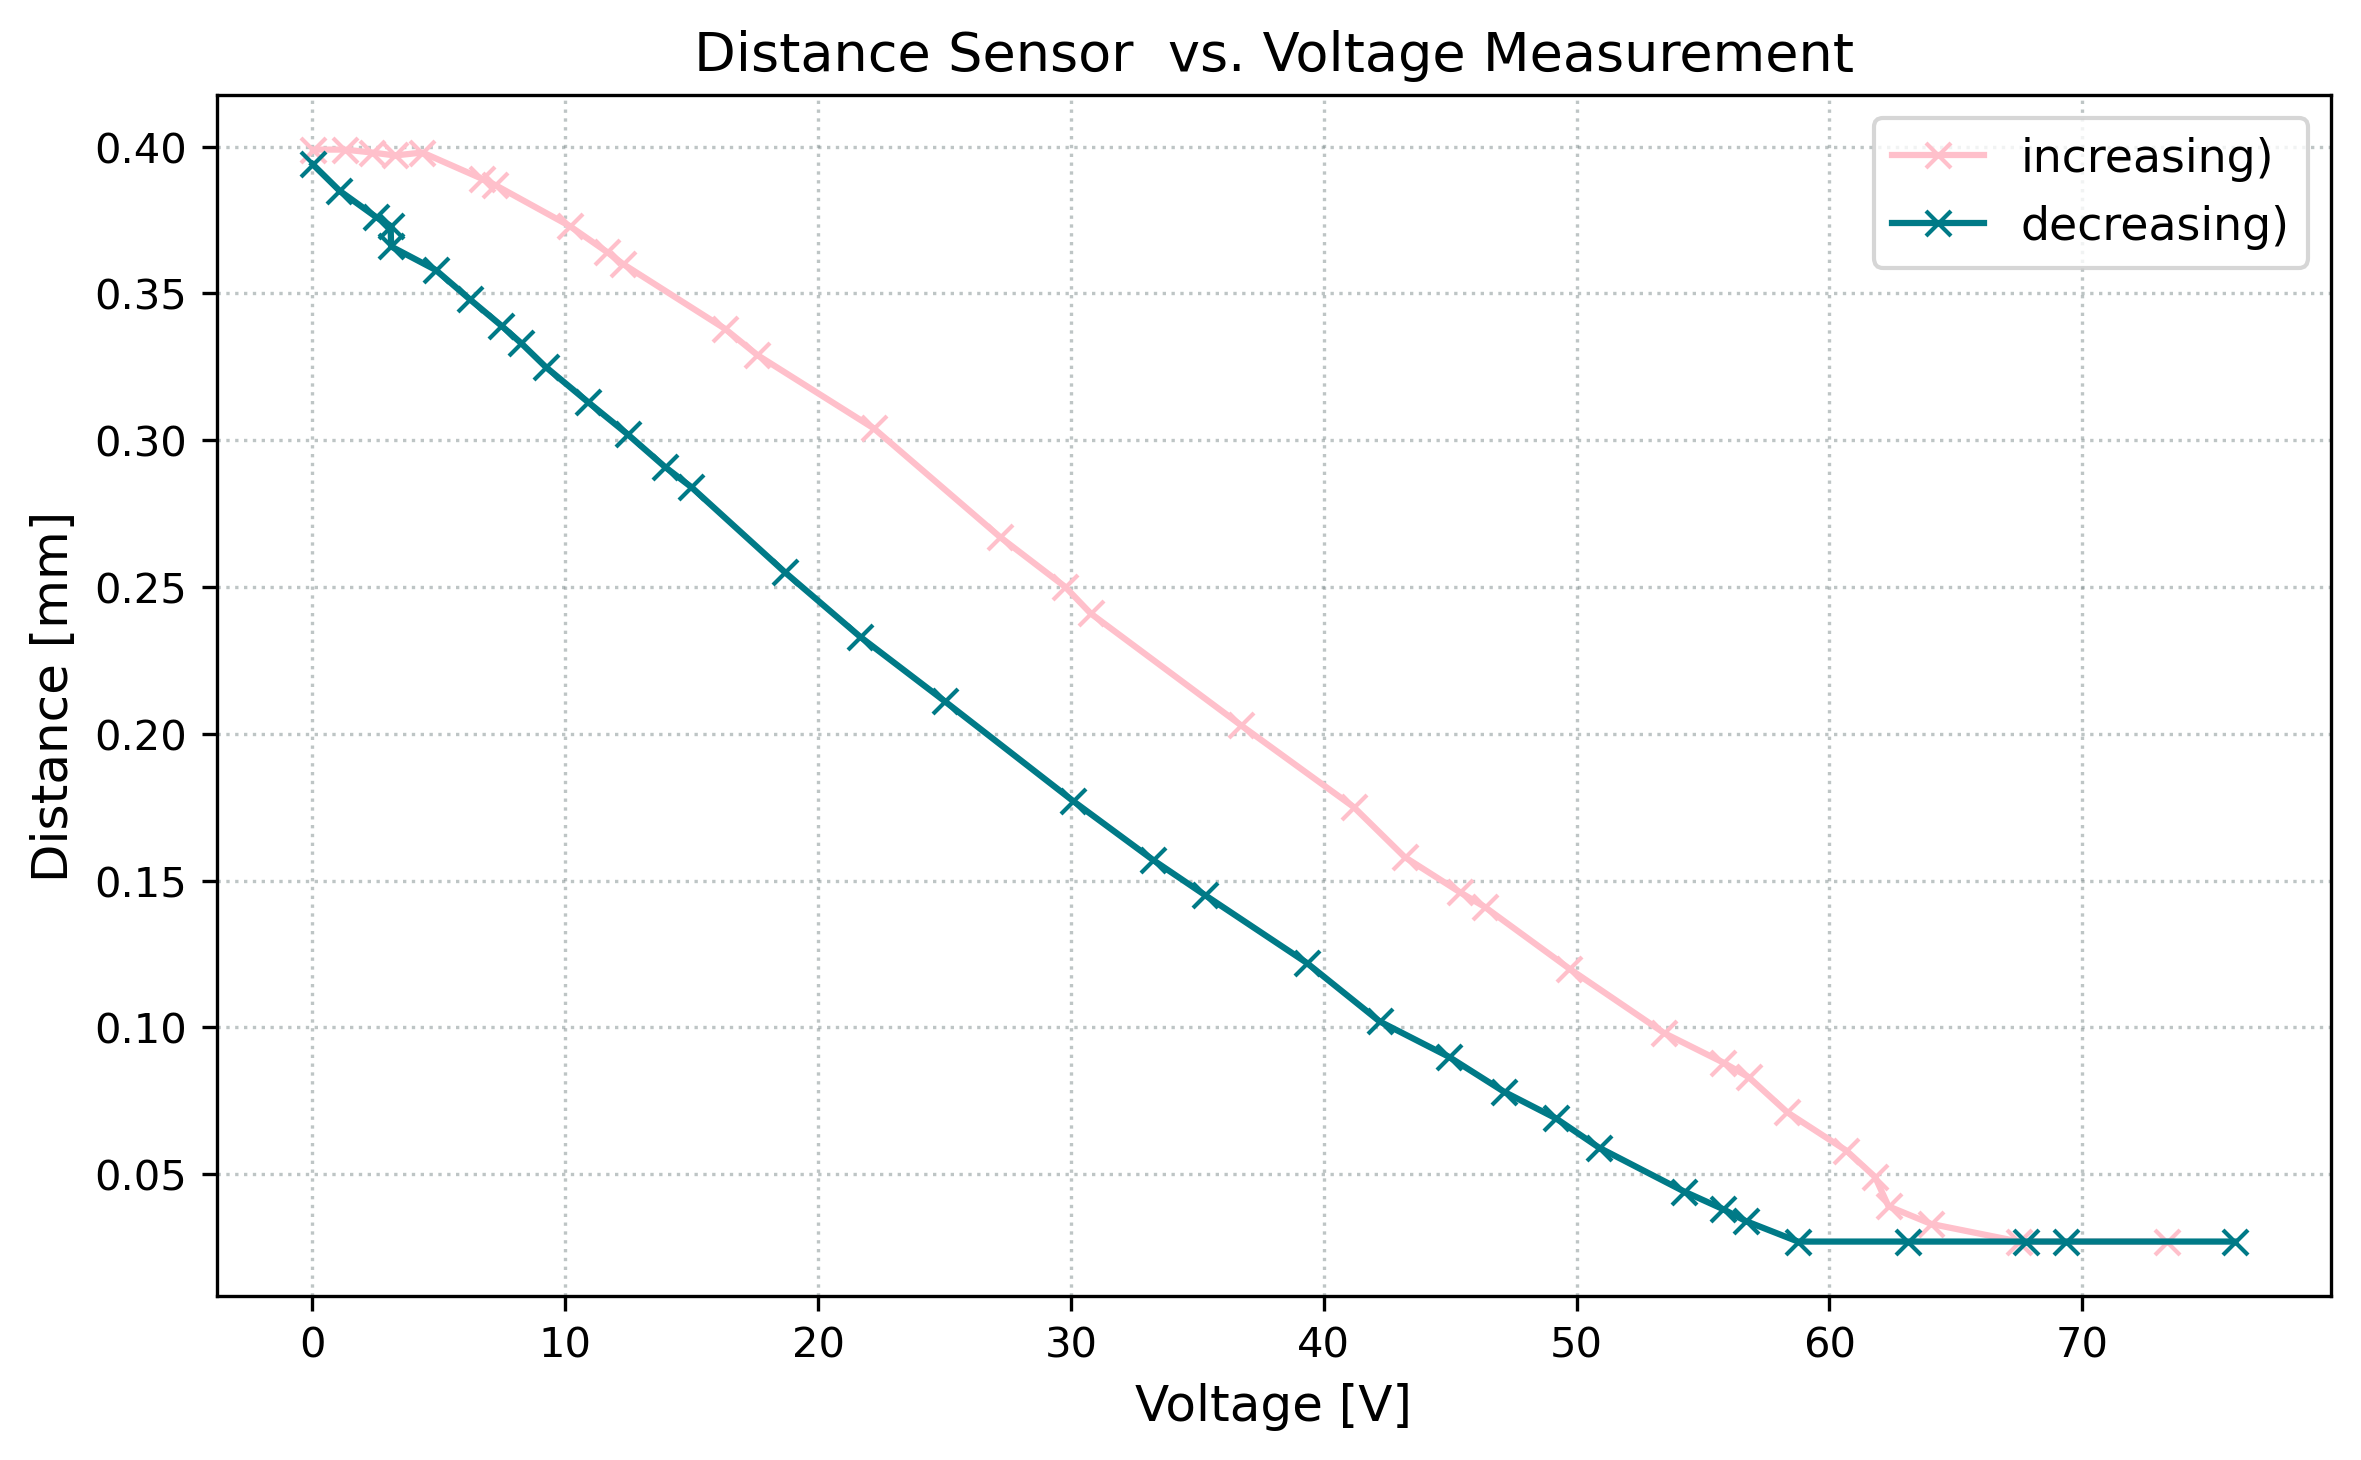

In [81]:
#nur sensor volatge

data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/divergence_voltage/div_V_voltage_increasing.csv',
    delimiter=','
)
voltage_div_up = data[:, 0]
divergence_x_up = data[:, 1] #i
divergence_x_error_up = data[:, 2]
divergence_y_up= data[:, 3]
divergence_y_error_up = data[:, 4]
M2_x_up = data[:, 5]
M2_x_error_up = data[:, 6]
M2_y_up = data[:, 7]
M2_y_error_up = data[:, 8]

voltage_sensor_up = data[:, 11]
distance_sensor_up = data[:, 12]

##error messergät und sensor needed

fig, (ax1) = plt.subplots(figsize=(8, 5))
#ax2 = ax1.twinx()

ax1.plot(voltage_sensor_up, distance_sensor_up, '-x', color='pink', label=r'increasing)')

data2 = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/divergence_voltage/div_V_voltage_decreasing.csv',
    delimiter=','
)
voltage_div_down = data2[:, 0]
divergence_x_down = data2[:, 1] #i
divergence_x_error_down = data2[:, 2]
divergence_y_down= data2[:, 3]
divergence_y_error_down = data2[:, 4]
M2_x_down = data2[:, 5]
M2_x_error_down = data2[:, 6]
M2_y_down = data2[:, 7]
M2_y_error_down = data2[:, 8]

voltage_sensor_down = data2[:, 11]
distance_sensor_down = data2[:, 12]

##error messergät und sensor needed

ax1.plot(voltage_sensor_down, distance_sensor_down, '-x', color='#007A87', label=r'decreasing)')




plt.xlabel(r"Voltage [V]")
plt.ylabel(r"Distance [mm]")
plt.title('Distance Sensor  vs. Voltage Measurement')
#plt.xlim(0, 50)
plt.legend()
plt.tight_layout()
#plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/divergence_vs_mechanival_displacement_full.pdf")

plt.show()